# 04 — Logistic Regression

Predict TMB-high status (≥10 mut/Mb) using standard and Firth's penalized logistic regression.

**Key issues:**
- Quasi-complete separation in rare cancer types (0% or 100% TMB-high)
- Firth's bias-corrected logistic regression handles this

**Outputs:** Odds ratios, ROC curve, confusion matrix, calibration

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as sp_stats
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.plotting import set_style, save_fig, plot_roc_curve, plot_confusion_matrix
from src.stats import fit_firth_logistic, likelihood_ratio_test, extract_model_summary
from src.preprocessing import get_model_df

set_style()
FIGURES_DIR = PROJECT_ROOT / "figures"

df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "tmb_merged.parquet")
print(f"Loaded {df.shape[0]} samples")

Loaded 10953 samples


## 1. TMB-High Prevalence and Class Balance

In [2]:
print(f"Overall TMB-high prevalence: {df['tmb_high'].mean():.1%}")
print(f"  TMB-high (n): {df['tmb_high'].sum()}")
print(f"  TMB-low  (n): {(df['tmb_high'] == 0).sum()}")

# Cancer types with potential separation issues
if "cancer_type" in df.columns:
    ct_prev = df.groupby("cancer_type")["tmb_high"].agg(["mean", "sum", "count"])
    ct_prev.columns = ["prevalence", "n_high", "n_total"]
    ct_prev = ct_prev.sort_values("prevalence")
    
    separation_risk = ct_prev[(ct_prev["prevalence"] == 0) | (ct_prev["prevalence"] == 1)]
    print(f"\nCancer types with 0% or 100% TMB-high ({len(separation_risk)}):")
    if len(separation_risk) > 0:
        print(separation_risk.to_string())
    else:
        print("  None (no complete separation risk)")
    
    near_sep = ct_prev[(ct_prev["prevalence"] < 0.02) | (ct_prev["prevalence"] > 0.98)]
    print(f"\nCancer types with near-separation (<2% or >98%) ({len(near_sep)}):")
    print(near_sep.to_string())

Overall TMB-high prevalence: 11.5%
  TMB-high (n): 1255
  TMB-low  (n): 9698

Cancer types with 0% or 100% TMB-high (5):
                                     prevalence  n_high  n_total
cancer_type                                                     
Pleural Mesothelioma                        0.0       0       87
Seminoma                                    0.0       0       63
Pheochromocytoma                            0.0       0      147
Non-Seminomatous Germ Cell Tumor            0.0       0       86
Miscellaneous Neuroepithelial Tumor         0.0       0       31

Cancer types with near-separation (<2% or >98%) (14):
                                     prevalence  n_high  n_total
cancer_type                                                     
Pleural Mesothelioma                   0.000000       0       87
Seminoma                               0.000000       0       63
Pheochromocytoma                       0.000000       0      147
Non-Seminomatous Germ Cell Tumor       0.000

## 2. Prepare Modeling Data

In [3]:
predictors = ["age_at_diagnosis", "cancer_type", "sex", "msi_status",
              "aneuploidy_score", "fraction_genome_altered"]
available_preds = [c for c in predictors if c in df.columns]

model_df = get_model_df(df, available_preds, "tmb_high")
print(f"Complete cases: {len(model_df)}")
print(f"TMB-high prevalence in model data: {model_df['tmb_high'].mean():.1%}")

Complete cases: 10325
TMB-high prevalence in model data: 11.6%


## 3. Standard Logistic Regression (statsmodels)

In [4]:
logit_formula = "tmb_high ~ age_at_diagnosis + C(cancer_type) + C(sex) + C(msi_status) + aneuploidy_score + fraction_genome_altered"

logit_model = sm.Logit.from_formula(logit_formula, data=model_df)
logit_result = logit_model.fit(method="bfgs", disp=0, maxiter=200)
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:               tmb_high   No. Observations:                 9251
Model:                          Logit   Df Residuals:                     9217
Method:                           MLE   Df Model:                           33
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.4087
Time:                        00:53:30   Log-Likelihood:                -1818.1
converged:                      False   LL-Null:                       -3074.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                 0.8726      0.727      1.200      0.230      -0.553       2.298
C(

## 4. Firth's Logistic Regression

In [5]:
# Prepare design matrix with dummy encoding for Firth
cat_cols_in_model = [c for c in ["cancer_type", "sex", "msi_status"] if c in model_df.columns]
X_firth = pd.get_dummies(model_df[available_preds], columns=cat_cols_in_model, drop_first=True)
X_firth = X_firth.apply(pd.to_numeric, errors="coerce").dropna(axis=1)
y_firth = model_df.loc[X_firth.index, "tmb_high"].astype(int)

print(f"Design matrix: {X_firth.shape}")
print(f"Features: {list(X_firth.columns[:10])}...")

firth_result = fit_firth_logistic(X_firth, y_firth)
print(f"\nFirth intercept: {firth_result['intercept']:.4f}")
print(f"Number of coefficients: {len(firth_result['coef'].flatten())}")
print(f"Converged in {firth_result['n_iter']} iterations")

Design matrix: (10325, 35)
Features: ['age_at_diagnosis', 'aneuploidy_score', 'fraction_genome_altered', 'cancer_type_Bladder Cancer', 'cancer_type_Breast Cancer', 'cancer_type_Cervical Cancer', 'cancer_type_Cholangiocarcinoma', 'cancer_type_Colorectal Cancer', 'cancer_type_Endometrial Cancer', 'cancer_type_Esophagogastric Cancer']...



Firth intercept: 1.2701
Number of coefficients: 35
Converged in 13 iterations


In [6]:
# Compare standard vs Firth coefficients for non-cancer-type variables
std_coefs = extract_model_summary(logit_result)
non_ct_std = std_coefs[~std_coefs["variable"].str.contains("cancer_type", case=False)].copy()

firth_coef_df = pd.DataFrame({
    "variable": firth_result["feature_names"],
    "coef_firth": firth_result["coef"].flatten(),
})
non_ct_firth = firth_coef_df[~firth_coef_df["variable"].str.contains("cancer_type", case=False)]

print("Standard logistic coefficients (non-cancer-type):")
print(non_ct_std[["variable", "coef", "p_value"]].to_string(index=False))
print("\nFirth logistic coefficients (non-cancer-type):")
print(non_ct_firth.to_string(index=False))

Standard logistic coefficients (non-cancer-type):
               variable      coef       p_value
              Intercept  0.872588  2.301280e-01
         C(sex)[T.MALE]  0.135625  1.810073e-01
   C(msi_status)[T.MSS] -4.817217 7.144297e-148
       age_at_diagnosis -0.007276  6.221602e-02
       aneuploidy_score  0.004905  4.899613e-01
fraction_genome_altered -0.026311  9.201401e-01

Firth logistic coefficients (non-cancer-type):
               variable  coef_firth
       age_at_diagnosis   -0.005611
       aneuploidy_score    0.003474
fraction_genome_altered   -0.025120
               sex_MALE    0.195491
         msi_status_MSS   -4.733457
         msi_status_nan   -4.694989


## 5. Odds Ratios

In [7]:
# Odds ratios from standard logistic regression
or_df = std_coefs.copy()
or_df["odds_ratio"] = np.exp(or_df["coef"])
or_df["or_ci_lower"] = np.exp(or_df["ci_lower"])
or_df["or_ci_upper"] = np.exp(or_df["ci_upper"])

# Display non-cancer-type ORs
or_display = or_df[~or_df["variable"].str.contains("cancer_type", case=False)]
print("Odds Ratios (95% CI):")
or_display[["variable", "odds_ratio", "or_ci_lower", "or_ci_upper", "p_value"]].style.format({
    "odds_ratio": "{:.3f}",
    "or_ci_lower": "{:.3f}",
    "or_ci_upper": "{:.3f}",
    "p_value": "{:.2e}",
})

Odds Ratios (95% CI):


,variable,odds_ratio,or_ci_lower,or_ci_upper,p_value
0,Intercept,2.393,0.575,9.952,2.30e-01
30,C(sex)[T.MALE],1.145,0.939,1.397,1.81e-01
31,C(msi_status)[T.MSS],0.008,0.006,0.012,7.14e-148
32,age_at_diagnosis,0.993,0.985,1.000,6.22e-02
33,aneuploidy_score,1.005,0.991,1.019,4.90e-01
34,fraction_genome_altered,0.974,0.582,1.629,9.20e-01


## 6. Model Performance

In [8]:
# Standard logistic — in-sample predicted probabilities
y_prob_std = logit_result.predict()
y_pred_std = (y_prob_std >= 0.5).astype(int)
# Use the fitted model's endog (response) to ensure matching length
y_true = logit_result.model.endog.astype(int)

print("=== Standard Logistic Regression ===")
print(f"Samples used in model: {len(y_true)}")
print(classification_report(y_true, y_pred_std, target_names=["TMB-Low", "TMB-High"]))
print(f"AUC: {roc_auc_score(y_true, y_prob_std):.3f}")

=== Standard Logistic Regression ===
Samples used in model: 9251
              precision    recall  f1-score   support

     TMB-Low       0.93      0.99      0.96      8295
    TMB-High       0.80      0.36      0.50       956

    accuracy                           0.92      9251
   macro avg       0.87      0.68      0.73      9251
weighted avg       0.92      0.92      0.91      9251

AUC: 0.910


In [9]:
# Firth — predicted probabilities
y_prob_firth = firth_result["probabilities"]
y_pred_firth = firth_result["predictions"]

print("=== Firth Logistic Regression ===")
print(classification_report(y_firth, y_pred_firth, target_names=["TMB-Low", "TMB-High"]))
print(f"AUC: {roc_auc_score(y_firth, y_prob_firth):.3f}")

=== Firth Logistic Regression ===
              precision    recall  f1-score   support

     TMB-Low       0.94      0.98      0.96      9126
    TMB-High       0.74      0.49      0.59      1199

    accuracy                           0.92     10325
   macro avg       0.84      0.74      0.77     10325
weighted avg       0.91      0.92      0.91     10325

AUC: 0.920


  Saved: roc_curve_logistic.png, roc_curve_logistic.pdf


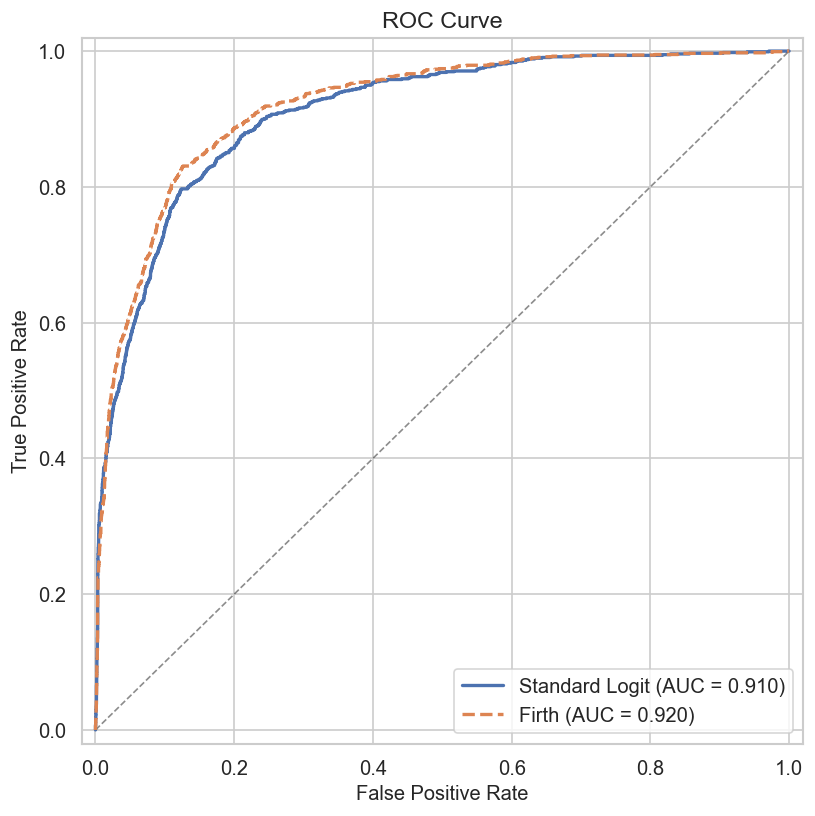

In [10]:
# ROC curves
fig = plot_roc_curve(y_true, y_prob_std, label="Standard Logit")

# Add Firth to same plot
from sklearn.metrics import roc_curve, auc
fpr_f, tpr_f, _ = roc_curve(y_firth, y_prob_firth)
auc_f = auc(fpr_f, tpr_f)
fig.axes[0].plot(fpr_f, tpr_f, lw=2, ls="--", label=f"Firth (AUC = {auc_f:.3f})")
fig.axes[0].legend(loc="lower right")

save_fig(fig, "roc_curve_logistic", FIGURES_DIR)
plt.show()

  Saved: confusion_matrix_logistic.png, confusion_matrix_logistic.pdf


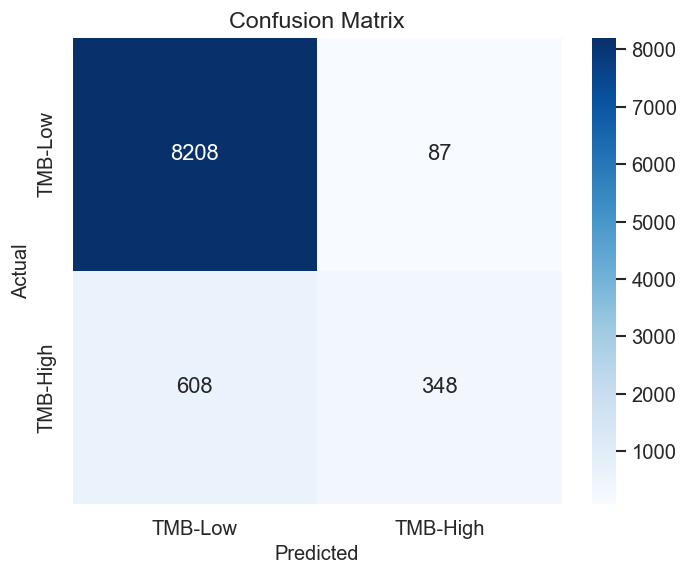

In [11]:
# Confusion matrix (standard logistic)
fig = plot_confusion_matrix(y_true, y_pred_std)
save_fig(fig, "confusion_matrix_logistic", FIGURES_DIR)
plt.show()

## 7. Likelihood Ratio Tests

In [12]:
# Full vs intercept-only
logit_null = sm.Logit.from_formula("tmb_high ~ 1", data=model_df).fit(disp=0)
lr_full_vs_null = likelihood_ratio_test(
    logit_null.llf, logit_result.llf,
    df_diff=int(logit_result.df_model)
)
print("Full vs Intercept-only:")
print(f"  Chi² = {lr_full_vs_null['chi2']:.2f}, df = {lr_full_vs_null['df']}, p = {lr_full_vs_null['p_value']:.2e}")

# Full vs cancer-type-only
logit_ct = sm.Logit.from_formula("tmb_high ~ C(cancer_type)", data=model_df).fit(method="bfgs", disp=0, maxiter=200)
lr_full_vs_ct = likelihood_ratio_test(
    logit_ct.llf, logit_result.llf,
    df_diff=int(logit_result.df_model - logit_ct.df_model)
)
print("\nFull vs Cancer-type-only:")
print(f"  Chi² = {lr_full_vs_ct['chi2']:.2f}, df = {lr_full_vs_ct['df']}, p = {lr_full_vs_ct['p_value']:.2e}")

Full vs Intercept-only:
  Chi² = 3779.91, df = 33, p = 0.00e+00



Full vs Cancer-type-only:
  Chi² = 1614.34, df = 4, p = 0.00e+00


## 8. Calibration

  Saved: calibration_plot.png, calibration_plot.pdf


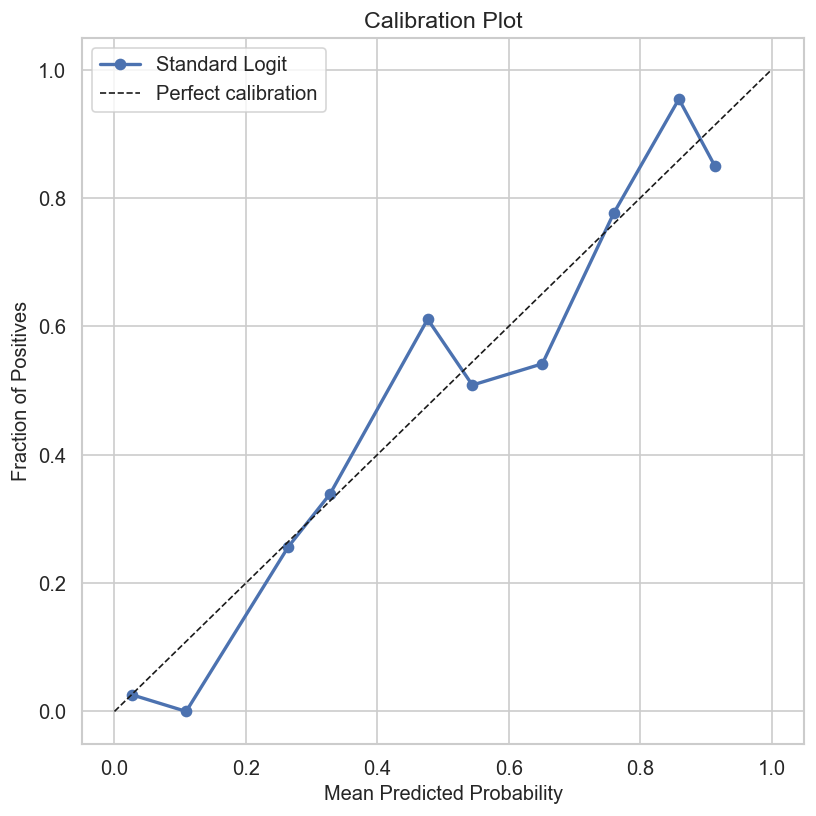

In [13]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_true, y_prob_std, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred, prob_true, "o-", label="Standard Logit", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Plot")
ax.legend()
fig.tight_layout()
save_fig(fig, "calibration_plot", FIGURES_DIR)
plt.show()

In [14]:
# Hosmer-Lemeshow test
def hosmer_lemeshow(y_true, y_prob, n_groups=10):
    """Hosmer-Lemeshow goodness-of-fit test."""
    data = pd.DataFrame({"y": np.asarray(y_true), "prob": np.asarray(y_prob)})
    data["group"] = pd.qcut(data["prob"], n_groups, duplicates="drop")
    
    obs = data.groupby("group", observed=False)["y"].sum()
    exp = data.groupby("group", observed=False)["prob"].sum()
    n = data.groupby("group", observed=False)["y"].count()
    
    hl_stat = (((obs - exp) ** 2) / (exp * (1 - exp / n))).sum()
    p_value = 1 - sp_stats.chi2.cdf(hl_stat, n_groups - 2)
    return {"hl_stat": hl_stat, "df": n_groups - 2, "p_value": p_value}

hl = hosmer_lemeshow(y_true, y_prob_std)
print(f"Hosmer-Lemeshow test:")
print(f"  Statistic: {hl['hl_stat']:.3f}")
print(f"  df: {hl['df']}")
print(f"  p-value: {hl['p_value']:.4f}")
print(f"  Interpretation: {'Adequate fit (p > 0.05)' if hl['p_value'] > 0.05 else 'Poor fit (p <= 0.05)'}")

Hosmer-Lemeshow test:
  Statistic: 13.481
  df: 8
  p-value: 0.0963
  Interpretation: Adequate fit (p > 0.05)


## 9. Summary

**Key findings:**
- Cancer type is the strongest predictor of TMB-high status
- Firth's logistic regression handles quasi-complete separation in rare cancer subtypes, providing finite coefficient estimates where standard logistic regression may diverge
- Odds ratios quantify the association between each predictor and TMB-high status
- The likelihood ratio test confirms that predictors beyond cancer type contribute significantly

**Clinical relevance:**
- TMB ≥ 10 mut/Mb is the FDA-approved threshold for pembrolizumab eligibility
- Understanding which clinical features predict TMB-high can inform clinical decision-making about which patients to prioritize for comprehensive genomic profiling